In [1]:
from graph_model import SimParams, build_graph, run_scenario, get_baseline_vmt
G = build_graph()

# Mode-Choice Equilibrium: Personal Car vs. Robo-Taxi

This notebook estimates a Wardrop user-equilibrium point for the `am_peak` period. A sweep over `robotaxi_share` changes the network state; at each share, travelers compare generalized cost and shift toward the lower-cost mode until the two costs are equal.

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Generalized Cost Assumptions

The cost functions use placeholder constants that should be replaced with observed fare, parking, and stated-preference data before making policy claims.

- Value of time: **$22/hour** for an urban commute-time sensitivity.
- Personal car fixed driving/parking cost: **$8.50/trip**, representing fuel, wear, and downtown parking.
- Robo-taxi per-trip fare: **$7.00/trip**, representing a subsidized or pooled urban fare placeholder.
- Robo-taxi pickup/repositioning wait: linearly decreases from **6.0 minutes** at near-zero adoption to **1.0 minute** at full adoption. Because the core simulator returns one network-wide average trip time, this access-time placeholder is folded into the robo-taxi travel-time term.

Cost formulas:

`Personal Car Cost = (Travel Time * Value of Time) + Fixed Driving/Parking Cost`

`Robo-Taxi Cost = (Travel Time * Value of Time) + Per-Trip Fare`

In [3]:
TIME_OF_DAY = "am_peak"
VALUE_OF_TIME_DOLLARS_PER_HOUR = 22.00
VALUE_OF_TIME_DOLLARS_PER_MIN = VALUE_OF_TIME_DOLLARS_PER_HOUR / 60.0
FIXED_DRIVING_PARKING_COST = 8.50
ROBOTAXI_PER_TRIP_FARE = 7.00
MAX_ROBOTAXI_PICKUP_WAIT_MIN = 6.0
MIN_ROBOTAXI_PICKUP_WAIT_MIN = 1.0

robotaxi_shares = np.round(np.arange(0.0, 1.01, 0.1), 1)

In [4]:
records = []
baseline_params = SimParams(time_of_day=TIME_OF_DAY, robotaxi_share=0.0)
baseline_vmt = get_baseline_vmt(G, baseline_params)

for robotaxi_share in robotaxi_shares:
    params = SimParams(time_of_day=TIME_OF_DAY, robotaxi_share=float(robotaxi_share))
    result = run_scenario(G, params)
    avg_trip_time_min = result["avg_trip_time_min"]

    robotaxi_pickup_wait_min = MAX_ROBOTAXI_PICKUP_WAIT_MIN - (
        MAX_ROBOTAXI_PICKUP_WAIT_MIN - MIN_ROBOTAXI_PICKUP_WAIT_MIN
    ) * robotaxi_share
    personal_car_travel_time_min = avg_trip_time_min
    robotaxi_travel_time_min = avg_trip_time_min + robotaxi_pickup_wait_min

    personal_car_cost = (
        personal_car_travel_time_min * VALUE_OF_TIME_DOLLARS_PER_MIN
        + FIXED_DRIVING_PARKING_COST
    )
    robotaxi_cost = (
        robotaxi_travel_time_min * VALUE_OF_TIME_DOLLARS_PER_MIN
        + ROBOTAXI_PER_TRIP_FARE
    )

    records.append({
        "robotaxi_share": robotaxi_share,
        "avg_trip_time_min": avg_trip_time_min,
        "robotaxi_pickup_wait_min": robotaxi_pickup_wait_min,
        "personal_car_cost": personal_car_cost,
        "robotaxi_cost": robotaxi_cost,
        "deadhead_vmt": result["deadhead_vmt"],
        "total_vmt": result["total_vmt"],
        "deadhead_share_of_vmt": result["deadhead_vmt"] / result["total_vmt"] if result["total_vmt"] else 0.0,
        "total_vmt_delta_from_baseline": result["total_vmt"] - baseline_vmt,
    })

sweep_df = pd.DataFrame(records)
sweep_df

,robotaxi_share,avg_trip_time_min,robotaxi_pickup_wait_min,personal_car_cost,robotaxi_cost,deadhead_vmt,total_vmt,deadhead_share_of_vmt,total_vmt_delta_from_baseline
0,0.0,12.781431,6.0,13.186525,13.886525,0.000000,2.269741e+06,0.000000,0.000000
1,0.1,12.804081,5.5,13.194830,13.711496,2280.647547,2.278876e+06,0.001001,9134.937530
2,0.2,12.827897,5.0,13.203562,13.536895,4561.295093,2.288011e+06,0.001994,18269.875060
3,0.3,12.852921,4.5,13.212738,13.362738,6841.942640,2.297146e+06,0.002978,27404.812590
4,0.4,12.879197,4.0,13.222372,13.189039,9122.590187,2.306281e+06,0.003956,36539.750120
5,0.5,12.906771,3.5,13.232483,13.015816,11403.237733,2.315416e+06,0.004925,45674.687651
6,0.6,12.909064,3.0,13.233324,12.833324,12802.692738,2.317314e+06,0.005525,47572.396553
7,0.7,12.871274,2.5,13.219467,12.636134,12802.692738,2.307718e+06,0.005548,37976.390576
8,0.8,12.835950,2.0,13.206515,12.439848,12802.692738,2.298122e+06,0.005571,28380.384599
9,0.9,12.802975,1.5,13.194424,12.244424,12802.692738,2.288526e+06,0.005594,18784.378622


In [5]:
cost_diff = sweep_df["robotaxi_cost"].to_numpy() - sweep_df["personal_car_cost"].to_numpy()
shares = sweep_df["robotaxi_share"].to_numpy()
pc_costs = sweep_df["personal_car_cost"].to_numpy()

equilibrium_share = None
equilibrium_cost = None
for idx in range(len(shares) - 1):
    left_diff = cost_diff[idx]
    right_diff = cost_diff[idx + 1]
    if left_diff == 0:
        equilibrium_share = shares[idx]
        equilibrium_cost = pc_costs[idx]
        break
    if left_diff * right_diff < 0:
        left_share = shares[idx]
        right_share = shares[idx + 1]
        equilibrium_share = left_share - left_diff * (right_share - left_share) / (right_diff - left_diff)
        equilibrium_cost = np.interp(equilibrium_share, shares, pc_costs)
        break

if equilibrium_share is None:
    closest_idx = int(np.argmin(np.abs(cost_diff)))
    equilibrium_share = shares[closest_idx]
    equilibrium_cost = pc_costs[closest_idx]

equilibrium_share, equilibrium_cost

(np.float64(0.38181818181818256), np.float64(13.220620512704103))

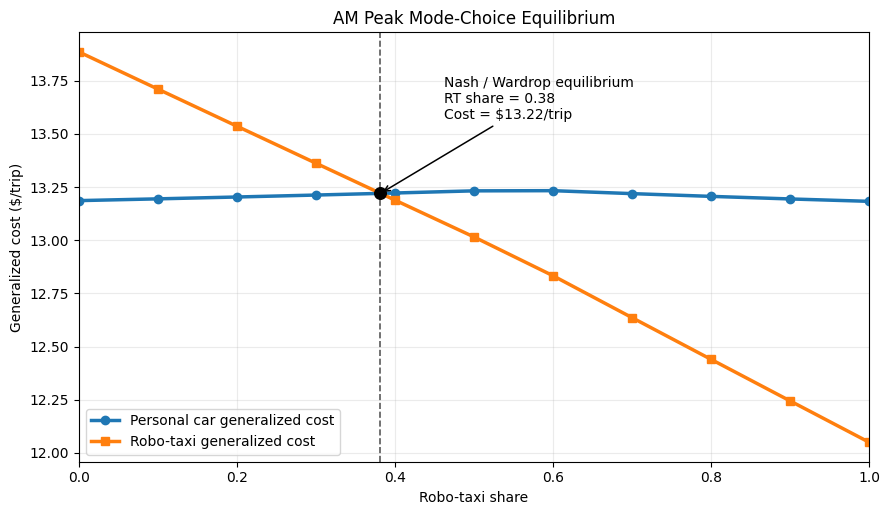

In [6]:
fig, ax = plt.subplots(figsize=(9, 5.25))

ax.plot(
    sweep_df["robotaxi_share"],
    sweep_df["personal_car_cost"],
    marker="o",
    linewidth=2.5,
    label="Personal car generalized cost",
)
ax.plot(
    sweep_df["robotaxi_share"],
    sweep_df["robotaxi_cost"],
    marker="s",
    linewidth=2.5,
    label="Robo-taxi generalized cost",
)

ax.scatter([equilibrium_share], [equilibrium_cost], color="black", s=70, zorder=5)
ax.axvline(equilibrium_share, color="0.35", linestyle="--", linewidth=1.2)
ax.annotate(
    f"Nash / Wardrop equilibrium\nRT share = {equilibrium_share:.2f}\nCost = ${equilibrium_cost:.2f}/trip",
    xy=(equilibrium_share, equilibrium_cost),
    xytext=(equilibrium_share + 0.08, equilibrium_cost + 0.35),
    arrowprops={"arrowstyle": "->", "color": "black", "lw": 1.1},
    fontsize=10,
)

ax.set_title("AM Peak Mode-Choice Equilibrium")
ax.set_xlabel("Robo-taxi share")
ax.set_ylabel("Generalized cost ($/trip)")
ax.set_xlim(0, 1)
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()

## Economic Intuition

Wardrop's user equilibrium says that travelers keep switching modes until no traveler can lower their own generalized cost by changing modes. To the left of the annotated crossing, the modeled robo-taxi option is more expensive because sparse adoption implies longer pickup/repositioning access time. To the right, the lower fixed fare dominates and travelers would prefer robo-taxis, pulling the system back toward the crossing. At the crossing, the marginal traveler is indifferent between personal driving and a robo-taxi.

Deadheading matters because empty repositioning vehicles consume capacity without carrying a passenger. As `robotaxi_share` rises, loaded robo-taxi trips and empty repositioning trips add VMT to the same arterial and freeway network used by personal cars. That raises utilization and can push average trip time upward, so the private mode-choice equilibrium can occur at a lower robo-taxi share than a model that ignores deadheading would suggest.

In [7]:
deadhead_summary = sweep_df[[
    "robotaxi_share",
    "avg_trip_time_min",
    "deadhead_vmt",
    "deadhead_share_of_vmt",
    "total_vmt_delta_from_baseline",
]].copy()
deadhead_summary

,robotaxi_share,avg_trip_time_min,deadhead_vmt,deadhead_share_of_vmt,total_vmt_delta_from_baseline
0,0.0,12.781431,0.000000,0.000000,0.000000
1,0.1,12.804081,2280.647547,0.001001,9134.937530
2,0.2,12.827897,4561.295093,0.001994,18269.875060
3,0.3,12.852921,6841.942640,0.002978,27404.812590
4,0.4,12.879197,9122.590187,0.003956,36539.750120
5,0.5,12.906771,11403.237733,0.004925,45674.687651
6,0.6,12.909064,12802.692738,0.005525,47572.396553
7,0.7,12.871274,12802.692738,0.005548,37976.390576
8,0.8,12.835950,12802.692738,0.005571,28380.384599
9,0.9,12.802975,12802.692738,0.005594,18784.378622
